In [1]:
from torchvision.models import get_model

from muppet import DEVICE
from muppet.benchmark.plot_explanation import plot_explanation_image
from muppet.benchmark.tools import load_imagenet_image
from muppet.explainers import RISEExplainer

/app/muppet/benchmark/plot_explanation.py:138: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


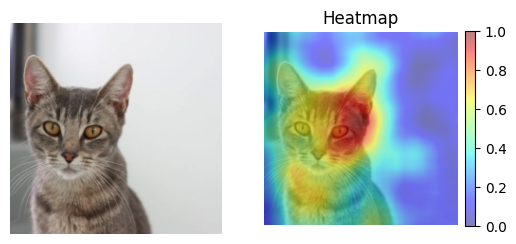

In [2]:
# Prepare VGG-16 model,
model = get_model(
    name="vgg16",
    weights="IMAGENET1K_V1",
)
model.to(DEVICE)

# Prepare the image to explain its classification
image = load_imagenet_image(
    "../../muppet/tests/data/cat.jpg"
)  # (1, 3, 224, 224)

# Explain the image class prediction using RISE method
rise_explainer = RISEExplainer(model=model)
heatmap = rise_explainer(example=image)  # (b=1, c=1, w=224, h=224)

# plot heatmap
plot_explanation_image(
    example=image[0],
    explanation=heatmap[0][0],
    figure_title="Heatmap",
)